In [13]:
!pip install -U pip setuptools wheel
!pip install protobuf
!pip install skl2onnx --only-binary :all:
!pip install onnxruntime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import skl2onnx
import onnxruntime as rt

In [14]:
df = pd.read_excel("/content/drive/MyDrive/Documents/UNSIKA/Tugas Akhir/Data Pendukung/Dataset.xlsx")
df = df.drop('Kerusakan', axis=1)
df.head()

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,...,G25,G26,G27,G28,G29,G30,G31,G32,G33,Kode Kerusakan
0,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


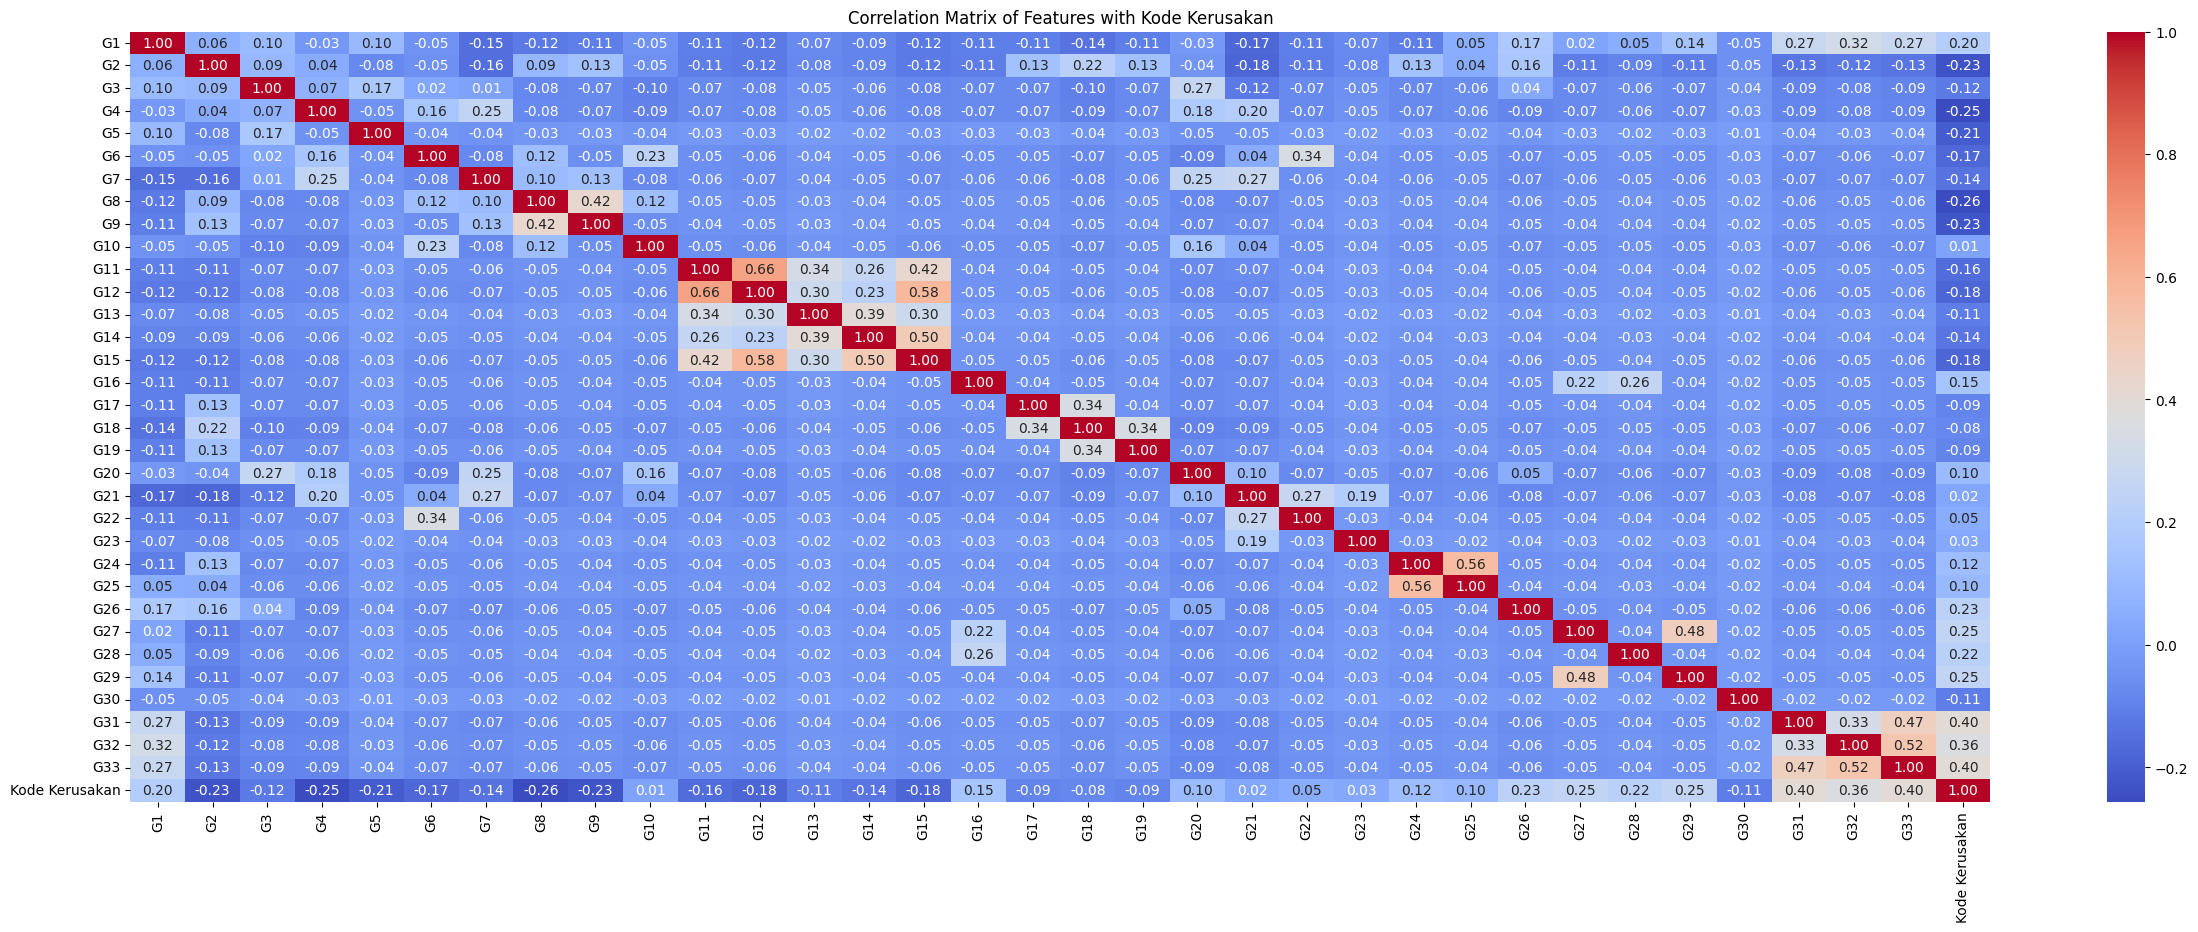

In [15]:
correlation_matrix = df.corr()

plt.figure(figsize=(30, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features with Kode Kerusakan')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Kode Kerusakan', axis=1)
y = df['Kode Kerusakan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(81, 33) (21, 33) (81,) (21,)


In [17]:
X_train

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,...,G24,G25,G26,G27,G28,G29,G30,G31,G32,G33
53,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
68,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
44,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
71,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
14,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
92,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [18]:
y_train

,Kode Kerusakan
53,5
22,2
68,7
44,5
98,10
...,...
60,6
71,7
14,2
92,10


In [19]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()
model.fit(X_train, y_train)

BernoulliNB()

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

y_prob = model.predict_proba(X_test)

try:
  roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
except ValueError:
  roc_auc = np.nan
  print("ROC AUC score cannot be calculated for this dataset.")

conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.8571
Precision: 0.8587
Recall: 0.8571
F1-score: 0.8373
ROC AUC: 0.9915
Confusion Matrix:
[[4 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 3 0 0 0 0 0 1 0]
 [0 0 0 2 0 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 0 0 2]]


In [21]:
new_data = pd.DataFrame({
    'G1': [1],
    'G2': [1],
    'G3': [1],
    'G4': [1],
    'G5': [0],
    'G6': [1],
    'G7': [0],
    'G8': [0],
    'G9': [0],
    'G10': [0],
    'G11': [0],
    'G12': [0],
    'G13': [0],
    'G14': [0],
    'G15': [0],
    'G16': [0],
    'G17': [0],
    'G18': [0],
    'G19': [0],
    'G20': [0],
    'G21': [0],
    'G22': [0],
    'G23': [0],
    'G24': [0],
    'G25': [0],
    'G26': [0],
    'G27': [0],
    'G28': [0],
    'G29': [0],
    'G30': [0],
    'G31': [0],
    'G32': [0],
    'G33': [0]
})

new_predictions = model.predict(new_data)
print("New Predictions:", new_predictions)

new_probabilities = model.predict_proba(new_data)
print("New Probabilities:")
new_probabilities

New Predictions: [1]
New Probabilities:


array([[9.77091627e-01, 1.02594621e-03, 2.29445691e-04, 1.00563788e-03,
        1.07268040e-03, 7.94578077e-04, 1.56334660e-03, 1.59831556e-02,
        5.63157212e-04, 6.70425253e-04]])

In [22]:
from skl2onnx.common.data_types import FloatTensorType

initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]
onnx_model = skl2onnx.convert_sklearn(model, initial_types=initial_type)

with open("bernoulli_nb_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())



In [23]:
sess = rt.InferenceSession("bernoulli_nb_model.onnx")
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name

new_data_np = new_data.to_numpy().astype(np.float32)

pred_onx = sess.run([label_name], {input_name: new_data_np})
print("Onnx new prediction:", pred_onx)

Onnx new prediction: [array([1], dtype=int64)]
